# Simulation_CLP_PI

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, FO_RT, Delay_RT
from package_LAB import PID_RT, LL_RT, IMC_Tuning


# Load data

In [26]:
#nameFile = 'RT_PID_FF_ventilo2026-03-28-20h20.txt'
nameFile = 'RT_PID_FF_ventilo2026-03-28-21h18.txt'



titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

tm = data['t'].values
MVm = data['MV'].values
MVPm = data['MVP'].values
MVIm = data['MVI'].values
MVDm = data['MVD'].values
MVFFm = data['MVFF'].values
PVm = data['PV'].values
DVm = data['DV'].values
SPm = data['SP'].values


In [27]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

TSim = 3300
Ts = 1 
N = int(TSim/Ts) + 1

t = []
Man = []

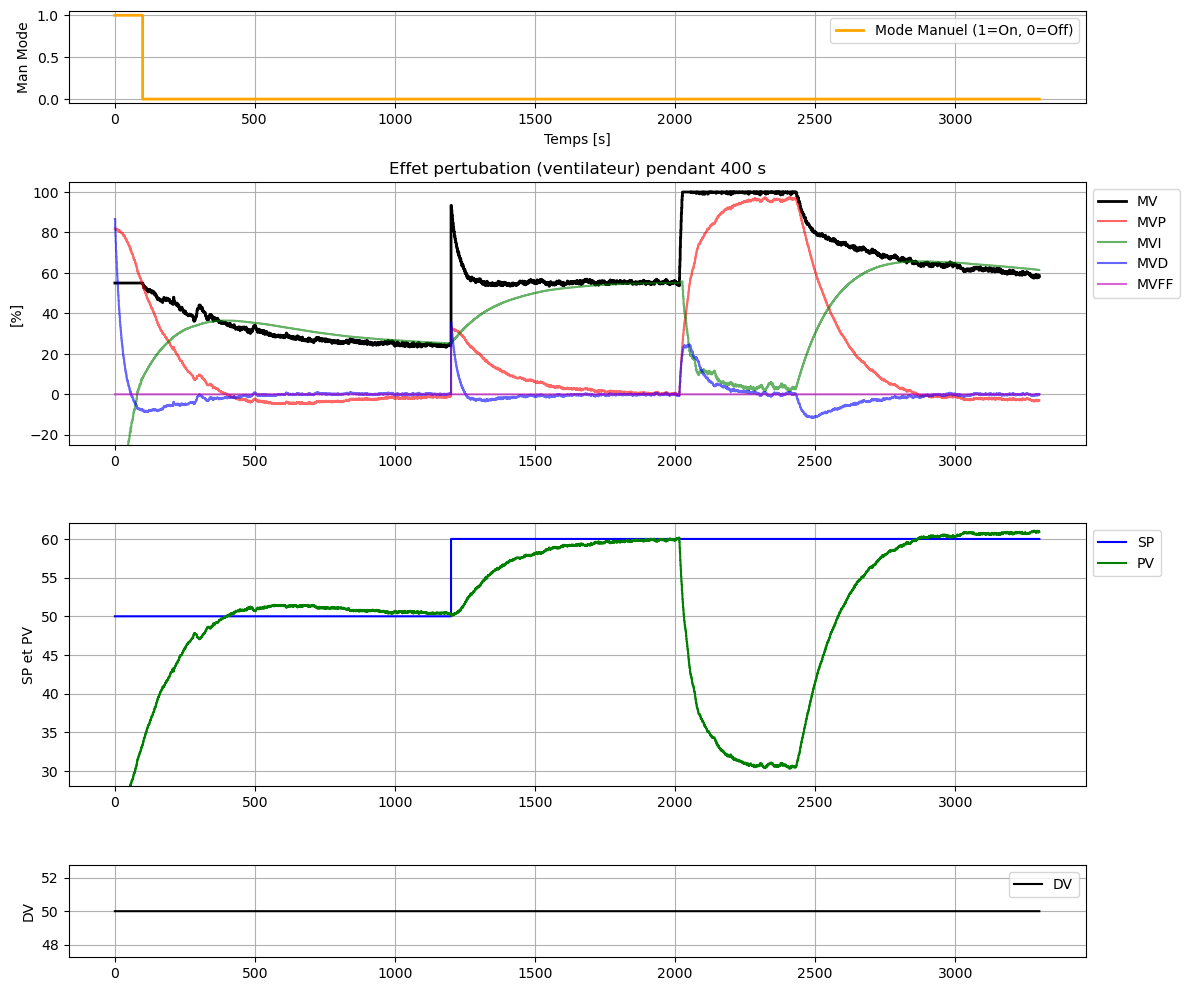

In [28]:
ManPath = {0: True, 100: False, 1500: False, TSim: False}
for i in range(1, N):

    t.append(i * Ts)

    SelectPath_RT(ManPath, t, Man)


plt.figure(figsize=(12, 10))

#MV
ax2 = plt.subplot2grid((12, 1), (2, 0), rowspan=4)
ax2.step(tm, MVm, 'k-', lw=2, label='MV', where='post')
ax2.step(tm, MVPm, 'r-', label='MVP', where='post', alpha=0.6)
ax2.step(tm, MVIm, 'g-', label='MVI', where='post', alpha=0.6)
ax2.step(tm, MVDm, 'b-', label='MVD', where='post', alpha=0.6)
ax2.step(tm, MVFFm, 'm-', label='MVFF', where='post', alpha=0.6)
ax2.set_ylabel('[%]')
ax2.set_title('Effet pertubation (ventilateur) pendant 400 s')
ax2.set_ylim(-25, 105)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True)

#SP, PV
ax3 = plt.subplot2grid((12, 1), (6, 0), rowspan=4)
ax3.step(tm, SPm, 'b-', label='SP', where='post')
ax3.step(tm, PVm, 'g-', label='PV', where='post')
#ax3.step(t, E, 'r-', label='Erreur', where='post')
ax3.set_ylabel('SP et PV')
ax3.set_ylim(28, 62)
ax3.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax3.grid(True)

#DV
ax4 = plt.subplot2grid((12, 1), (10, 0), rowspan=2)
ax4.step(tm, DVm, 'k-', label='DV', where='post')
ax4.set_ylabel('DV')
ax4.legend(loc='upper right')
ax4.grid(True)
 

#Mode Manuel
ax1 = plt.subplot2grid((12, 1), (0, 0), rowspan=2)
ax1.step(t, [int(m) for m in Man], 'orange', lw=2, label='Mode Manuel (1=On, 0=Off)', where='post')
ax1.set_ylabel('Man Mode')
ax1.set_xlabel('Temps [s]')
ax1.legend(loc='upper right')
ax1.grid(True)


plt.tight_layout()
plt.show()
